# Final Model & Interpretation

This notebook finalizes the selected machine learning model based on the model refinement results from Chapter 06.

The selected candidate is the tuned Balanced Logistic Regression model.
This notebook will:

- evaluate the final model on the held-out test set
- examine model coefficients
- identify the most influential features
- investigate model predictions and errors
- assess the model's limitations

In [6]:
# 1. Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

In [7]:
# load the data
data_path = "../data/healthcare-dataset-stroke-data.csv"
df = pd.read_csv(data_path)
df = df.drop(columns="id")
df = df[df["gender"] != "Other"]

# split the data into features and target
X = df.drop(columns=['stroke'])
y = df['stroke']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [8]:
best_lr = joblib.load(
    "../models/balanced_logistic_regression_final.joblib"
)

In [19]:
print(best_lr.get_params())

{'memory': None, 'steps': [('preprocessor', ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['age', 'avg_glucose_level', 'bmi']),
                                ('cat',
                                 Pipeline(steps=[('encoder',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['gender', 'ever_married', 'work_type',
                                  'Residence_type', 'smoking_status']),
                                ('binary', 'passthrough',
                                 ['hypertension', 'heart_disease'])])), ('classifier', LogisticRegression(C=0.01, class_weight='balanced', max_iter=1000,
                   random_state=42))], 'transform_input': None, 've

In [9]:
def evaluate_model(model, X_test, y_test, model_name=None, plot_cm=True):

    # Predictions
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    # Metrics
    metrics = pd.DataFrame({
        "Metric": [
            "Accuracy",
            "Precision",
            "Recall",
            "F1-score",
            "ROC-AUC"
        ],
        "Score": [
            accuracy_score(y_test, y_pred),
            precision_score(y_test, y_pred, zero_division=0),
            recall_score(y_test, y_pred, zero_division=0),
            f1_score(y_test, y_pred, zero_division=0),
            roc_auc_score(y_test, y_prob)
        ]
    })

    metrics["Score"] = metrics["Score"].round(3)

    if model_name:
        print(f"\n{'='*50}")
        print(f"{model_name}")
        print(f"{'='*50}")

    print(metrics)

    print("\nClassification Report\n")
    print(classification_report(y_test, y_pred))

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)

    if plot_cm:
        ConfusionMatrixDisplay(
            confusion_matrix=cm
        ).plot(cmap="Blues")

        plt.title(f"Confusion Matrix - {model_name}")
        plt.show()

    return {
        "metrics": metrics,
        "y_pred": y_pred,
        "y_prob": y_prob,
        "confusion_matrix": cm
    }

      Metric  Score
0   Accuracy  0.724
1  Precision  0.128
2     Recall  0.800
3   F1-score  0.221
4    ROC-AUC  0.839

Classification Report

              precision    recall  f1-score   support

           0       0.99      0.72      0.83       972
           1       0.13      0.80      0.22        50

    accuracy                           0.72      1022
   macro avg       0.56      0.76      0.53      1022
weighted avg       0.94      0.72      0.80      1022



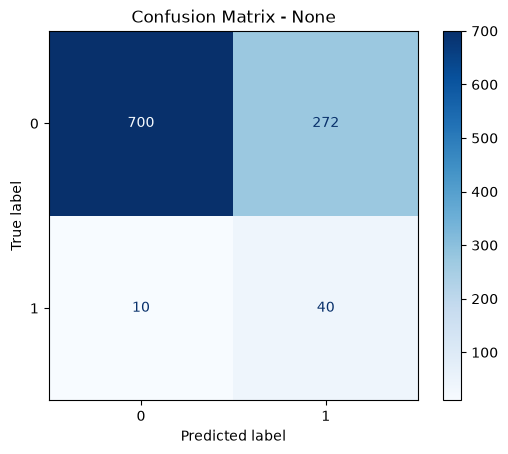

In [10]:
final_result = evaluate_model(
    best_lr,
    X_test,
    y_test,
    plot_cm=True
)

In [11]:
# Extract preprocessing and classifier steps
preprocessor = best_lr.named_steps["preprocessor"]
classifier = best_lr.named_steps["classifier"]

# Get transformed feature names
feature_names = preprocessor.get_feature_names_out()

# Get logistic regression coefficients
coefficients = classifier.coef_[0]

# Create a coefficient table
coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

# Absolute coefficient for ranking
coef_df["Abs_Coefficient"] = coef_df["Coefficient"].abs()

# Sort by importance
coef_df = coef_df.sort_values(
    "Abs_Coefficient",
    ascending=False
)

coef_df.head(15)

,Feature,Coefficient,Abs_Coefficient
0,num__age,1.340103,1.340103
18,binary__hypertension,0.351229,0.351229
1,num__avg_glucose_level,0.222705,0.222705
19,binary__heart_disease,0.161808,0.161808
16,cat__smoking_status_never smoked,-0.146078,0.146078
17,cat__smoking_status_smokes,0.090832,0.090832
15,cat__smoking_status_formerly smoked,0.077120,0.077120
12,cat__Residence_type_Rural,-0.068523,0.068523
13,cat__Residence_type_Urban,0.068245,0.068245
4,cat__gender_Male,-0.028206,0.028206


In [12]:
positive_features = (
    coef_df[coef_df["Coefficient"] > 0]
    .sort_values("Coefficient", ascending=False)
)

negative_features = (
    coef_df[coef_df["Coefficient"] < 0]
    .sort_values("Coefficient")
)

print("Positive coefficients:")
display(positive_features.head(10))

print("Negative coefficients:")
display(negative_features.head(10))

Positive coefficients:


,Feature,Coefficient,Abs_Coefficient
0,num__age,1.340103,1.340103
18,binary__hypertension,0.351229,0.351229
1,num__avg_glucose_level,0.222705,0.222705
19,binary__heart_disease,0.161808,0.161808
17,cat__smoking_status_smokes,0.090832,0.090832
15,cat__smoking_status_formerly smoked,0.077120,0.077120
13,cat__Residence_type_Urban,0.068245,0.068245
3,cat__gender_Female,0.027928,0.027928
6,cat__ever_married_Yes,0.020748,0.020748
9,cat__work_type_Private,0.017844,0.017844


Negative coefficients:


,Feature,Coefficient,Abs_Coefficient
16,cat__smoking_status_never smoked,-0.146078,0.146078
12,cat__Residence_type_Rural,-0.068523,0.068523
4,cat__gender_Male,-0.028206,0.028206
14,cat__smoking_status_Unknown,-0.022152,0.022152
5,cat__ever_married_No,-0.021026,0.021026
11,cat__work_type_children,-0.015042,0.015042
8,cat__work_type_Never_worked,-0.005591,0.005591
10,cat__work_type_Self-employed,-0.001363,0.001363


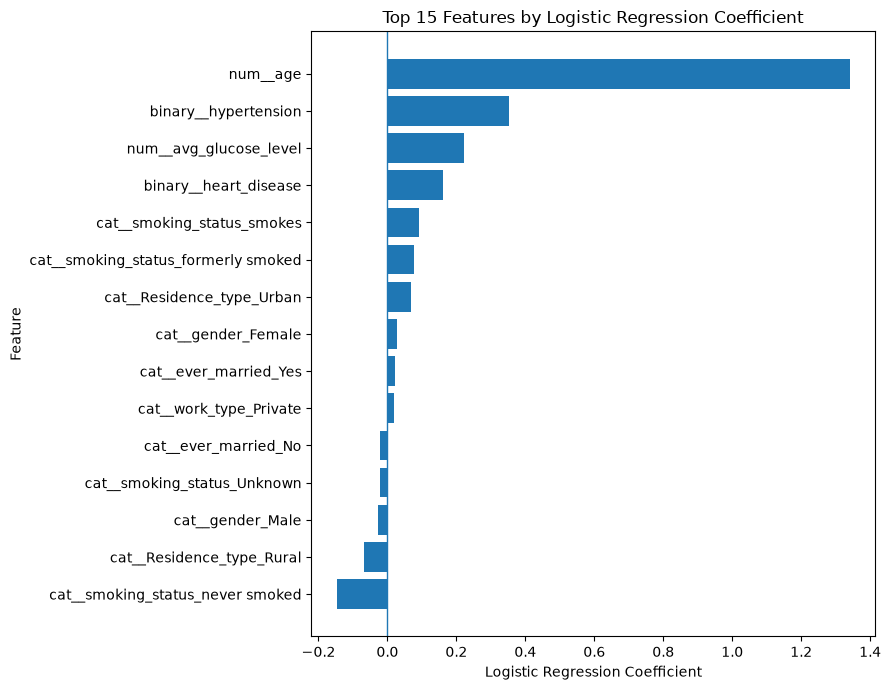

In [13]:
top_features = (
    coef_df
    .head(15)
    .sort_values("Coefficient")
)

plt.figure(figsize=(9, 7))

plt.barh(
    top_features["Feature"],
    top_features["Coefficient"]
)

plt.axvline(0, linewidth=1)

plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("Feature")
plt.title("Top 15 Features by Logistic Regression Coefficient")

plt.tight_layout()
plt.show()

### Coefficient Interpretation

The Logistic Regression coefficients provide an interpretable measure
of how each transformed feature contributes to the model's predicted
log-odds of stroke.

Positive coefficients indicate an association with higher predicted
stroke risk, while negative coefficients indicate an association with
lower predicted stroke risk.

Because continuous variables were standardized during preprocessing,
their coefficients can be compared based on their relative magnitude.
Categorical variables are interpreted relative to their omitted/reference
category.

The largest coefficients will be examined to identify the variables
that contribute most strongly to the model's predictions.

These associations should not be interpreted as causal relationships.

In [20]:
test_results = X_test.copy()

test_results["actual"] = y_test
test_results["predicted"] = final_result["y_pred"]
test_results["probability"] = final_result["y_prob"]

false_negatives = test_results[
    (test_results["actual"] == 1) &
    (test_results["predicted"] == 0)
]

false_positives = test_results[
    (test_results["actual"] == 0) &
    (test_results["predicted"] == 1)
]

In [21]:
false_negatives.describe(include="all")

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,actual,predicted,probability
count,10,10.000000,10.0,10.0,10,10,10,10.000000,9.000000,10,10.0,10.0,10.000000
unique,2,NaN,NaN,NaN,2,3,2,NaN,NaN,4,NaN,NaN,NaN
top,Female,NaN,NaN,NaN,Yes,Private,Rural,NaN,NaN,Unknown,NaN,NaN,NaN
freq,5,NaN,NaN,NaN,8,8,7,NaN,NaN,4,NaN,NaN,NaN
mean,NaN,41.300000,0.0,0.0,NaN,NaN,NaN,83.978000,32.077778,NaN,1.0,0.0,0.260879
std,NaN,12.875903,0.0,0.0,NaN,NaN,NaN,14.381995,6.357629,NaN,0.0,0.0,0.126061
min,NaN,14.000000,0.0,0.0,NaN,NaN,NaN,57.930000,25.400000,NaN,1.0,0.0,0.046882
25%,NaN,38.250000,0.0,0.0,NaN,NaN,NaN,77.907500,29.400000,NaN,1.0,0.0,0.213208
50%,NaN,40.500000,0.0,0.0,NaN,NaN,NaN,85.175000,29.900000,NaN,1.0,0.0,0.229820
75%,NaN,46.500000,0.0,0.0,NaN,NaN,NaN,95.275000,32.000000,NaN,1.0,0.0,0.323268


In [22]:
true_positives = test_results[
    (test_results["actual"] == 1) &
    (test_results["predicted"] == 1)
]

true_positives.describe(include="all")

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,actual,predicted,probability
count,40,40.000000,40.000000,40.000000,40,40,40,40.00000,38.000000,40,40.0,40.0,40.000000
unique,2,NaN,NaN,NaN,2,3,2,NaN,NaN,4,NaN,NaN,NaN
top,Female,NaN,NaN,NaN,Yes,Private,Urban,NaN,NaN,never smoked,NaN,NaN,NaN
freq,24,NaN,NaN,NaN,36,26,24,NaN,NaN,17,NaN,NaN,NaN
mean,NaN,74.650000,0.300000,0.275000,NaN,NaN,NaN,150.43225,29.565789,NaN,1.0,1.0,0.774830
std,NaN,6.863318,0.464095,0.452203,NaN,NaN,NaN,61.59970,6.054539,NaN,0.0,0.0,0.081792
min,NaN,57.000000,0.000000,0.000000,NaN,NaN,NaN,66.72000,20.100000,NaN,1.0,1.0,0.556315
25%,NaN,71.000000,0.000000,0.000000,NaN,NaN,NaN,97.87250,25.875000,NaN,1.0,1.0,0.711003
50%,NaN,78.000000,0.000000,0.000000,NaN,NaN,NaN,128.91500,27.700000,NaN,1.0,1.0,0.783214
75%,NaN,79.250000,1.000000,1.000000,NaN,NaN,NaN,206.14750,32.825000,NaN,1.0,1.0,0.825166


In [23]:
import shap

In [24]:
print(shap.__version__)

0.52.0


In [39]:
# Extract preprocessing and classifier
preprocessor = best_lr.named_steps["preprocessor"]
classifier = best_lr.named_steps["classifier"]

# Transform training and test data
X_train_processed = preprocessor.transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Get transformed feature names
feature_names = preprocessor.get_feature_names_out()

# Convert transformed data to DataFrame
X_train_shap = pd.DataFrame(
    X_train_processed.toarray()
    if hasattr(X_train_processed, "toarray")
    else X_train_processed,
    columns=feature_names,
    index=X_train.index
)

X_test_shap = pd.DataFrame(
    X_test_processed.toarray()
    if hasattr(X_test_processed, "toarray")
    else X_test_processed,
    columns=feature_names,
    index=X_test.index
)

In [42]:
# Convert feature names to pandas Index
feature_names = pd.Index(
    preprocessor.get_feature_names_out()
)

# Clean feature names
clean_feature_names = (
    feature_names
    .str.replace("num__", "", regex=False)
    .str.replace("binary__", "", regex=False)
    .str.replace("cat__", "", regex=False)
)

# Apply cleaned names
X_train_shap.columns = clean_feature_names
X_test_shap.columns = clean_feature_names

In [43]:
explainer = shap.LinearExplainer(
    classifier,
    X_train_shap
)

Background dataset has 4087 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=4087 when initializing the masker.


In [44]:
shap_values = explainer(X_test_shap)

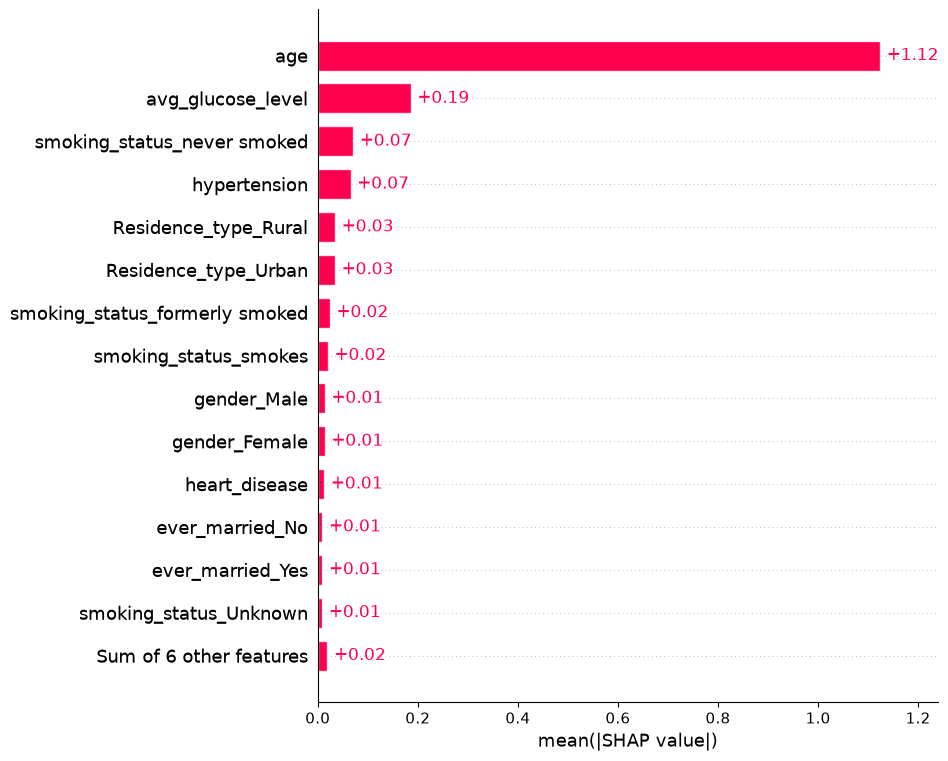

In [45]:
shap.plots.bar(
    shap_values,
    max_display=15
)

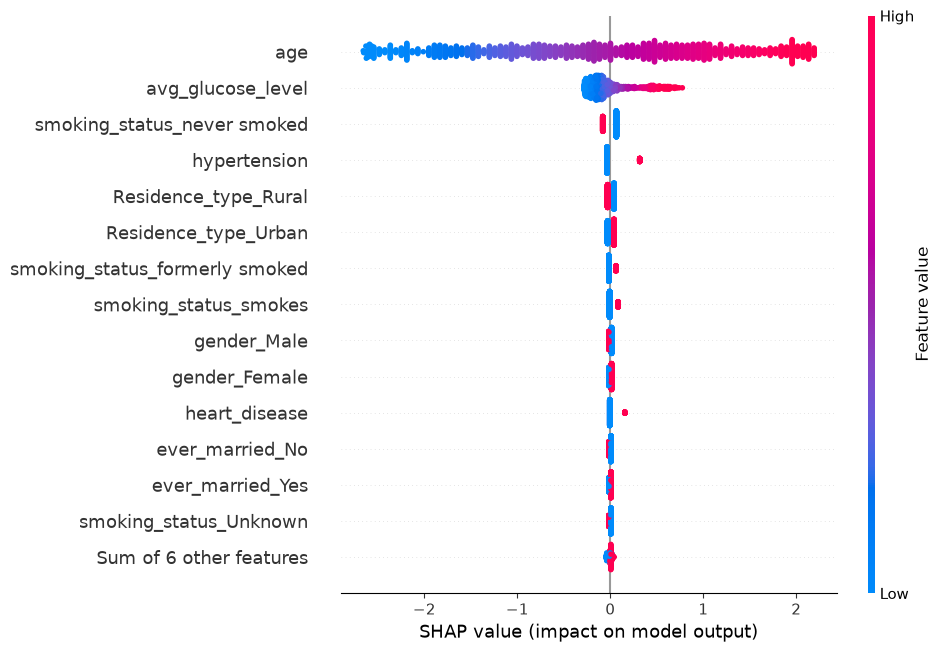

In [46]:
shap.plots.beeswarm(
    shap_values,
    max_display=15
)